In [35]:
import pandas as pd

# load the three files
disability = pd.read_csv("./data/disability_prevalence.csv")
demographics = pd.read_csv("./data/state_demographics.csv")
fips_lookup = pd.read_csv("./data/state_fips_lookup.csv")

# state abbreviations to names
STATE_NAMES = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
}

disability["state_abbr"] = (disability["state_name"].str.strip().map(STATE_NAMES))
demographics["state_abbr"] = (demographics["state_abbr"].str.strip().str.upper())


fips_lookup["state_name"] = fips_lookup["state_name"].str.strip()

# make sure abbreviation is upper-case
fips_lookup["state_abbr"] = fips_lookup["state_abbr"].str.strip().str.upper()
fips_lookup = fips_lookup.rename(columns={"state": "state_name", "abbreviation": "state_abbr", "fips_code": "fips"})



In [ ]:
# Keep one lookup row per state abbreviation for the joins.
keys = fips_lookup[["state_name", "state_abbr", "fips"]].drop_duplicates("state_abbr")

# source columns
disability_source = disability[["state_name", "year", "pct_with_disability", "population_with_disability"]]
demographics_source = demographics[["state_abbr", "total_population", "median_household_income", "pct_rural"]]

# add fips codes
disability_for_merge = disability_source.merge(keys, on="state_name", how="left", validate="many_to_one")

# add matching state codes from demographics
demographics_for_merge = demographics_source.merge(keys, on="state_abbr", how="left", validate="many_to_one")

combined = demographics_for_merge.merge(
    disability_for_merge[
        [
            "state_abbr",
            "state_name",
            "year",
            "pct_with_disability",
            "population_with_disability",
        ]
    ],
    on="state_abbr",
    how="left",
    suffixes=("_demographics", "_disability"),
    validate="one_to_one",
)

# fill the state name from either source and remove merge-only columns
combined["state_name"] = combined["state_name_demographics"].fillna(combined["state_name_disability"])
combined = combined.drop(columns=["state_name_demographics", "state_name_disability"])

combined = combined[
    [
        "state_abbr",
        "state_name",
        "fips",
        "year",
        "total_population",
        "median_household_income",
        "pct_rural",
        "pct_with_disability",
        "population_with_disability",
    ]
]

# kep only complete rows in the final analytical dataset
combined = combined.dropna().reset_index(drop=True)

display(combined)

combined.to_csv("cleaned_dataset.csv", index=False)


,state_abbr,state_name,fips,year,total_population,median_household_income,pct_rural,pct_with_disability,population_with_disability
0,AL,Alabama,1,2023.0,5108468,59609,42.1,16.2,398500.0
1,AK,Alaska,2,2023.0,733406,86370,33.9,14.8,72300.0
2,AZ,Arizona,4,2023.0,7431344,72581,10.2,13.9,712400.0
3,AR,Arkansas,5,2023.0,3067732,56335,43.8,17.1,265800.0
4,CA,California,6,2023.0,38965193,91905,5.0,11.4,3612900.0
5,CO,Colorado,8,2023.0,5877610,87598,13.8,11.8,521600.0
6,CT,Connecticut,9,2023.0,3617176,90213,12.0,12.6,334700.0
7,DE,Delaware,10,2023.0,1031890,79325,16.7,14.2,98400.0
8,FL,Florida,12,2023.0,22610726,67917,8.8,13.7,2458300.0
9,GA,Georgia,13,2023.0,11029227,71355,24.9,13.1,1123600.0


In [37]:
# get overall percentage of disability per state
total_population = combined["total_population"].sum()
total_disabled = (combined["total_population"] * combined["pct_with_disability"].fillna(0) / 100).round().astype(int)

# overall disability in total
overall_disabled = total_disabled.sum() / total_population * 100
print(overall_disabled)


12.801322333090088


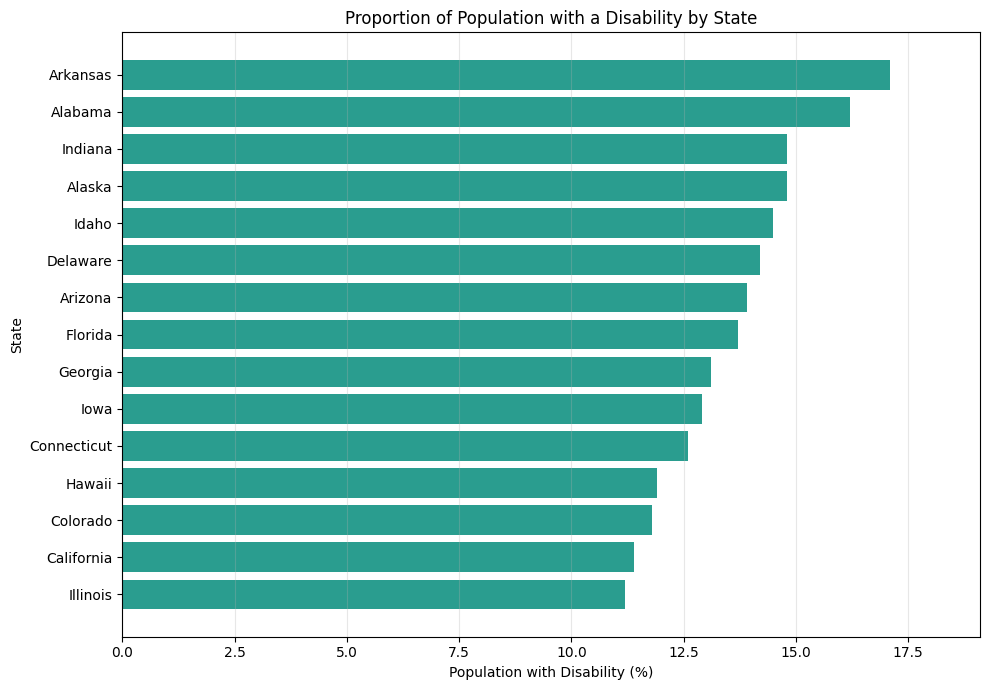

In [38]:
import matplotlib.pyplot as plt

proportional_data = combined.dropna(subset=["pct_with_disability"]).sort_values("pct_with_disability")

plt.figure(figsize=(10, 7))
plt.barh(proportional_data["state_name"], proportional_data["pct_with_disability"],color="#2a9d8f")

plt.title("Proportion of Population with a Disability by State")
plt.xlabel("Population with Disability (%)")
plt.ylabel("State")
plt.xlim(0, proportional_data["pct_with_disability"].max() + 2)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
